In [9]:
import numpy as np
import jax.random as jr
import jax
import jax.numpy as jnp
import timeit

from generator import init_inputs, make_net, generate_samples
from fosters_method import mom4_jax


def compute_time(noise_size, hidden_dim, num_layers, bm_dim, num_samples, use_gan=True, print_results=True):
    key = jr.key(0)
    key_net, key_inputs, key_method = jr.split(key, 3)
    w, hh, triu_indices = init_inputs(key_inputs, num_samples, bm_dim)
    if use_gan:
        net = make_net(key_net, noise_size, hidden_dim, num_layers)
        fun = lambda hh_in: generate_samples(key_method, net, triu_indices, w, hh_in)
    else:
        fun = lambda hh_in: mom4_jax(key_method, triu_indices, w, hh_in, None)
    
    # without feeding hh
    fn_without = lambda : jax.block_until_ready(fun(None))
    fn_without()  # warmup
    time_without_hh = timeit.repeat(fn_without, number=100, repeat=20)  # measure
    
    # with feeding hh
    fn_with = lambda : jax.block_until_ready(fun(hh))
    fn_with()  # warmup
    time_with_hh = timeit.repeat(fn_with, number=100, repeat=20)  # measure
    
    # compute mean and stdev
    mean_without_hh = np.mean(time_without_hh)/100
    stdev_without_hh = np.std(time_without_hh)/100
    mean_with_hh = np.mean(time_with_hh)/100
    stdev_with_hh = np.std(time_with_hh)/100
    if print_results:
        print(f"Without feeding hh: {mean_without_hh:.4} ± {stdev_without_hh:.4} seconds")
        print(f"With feeding hh: {mean_with_hh:.4} ± {stdev_with_hh:.4} seconds")
    return mean_without_hh, mean_with_hh

In [2]:
gan_without_hh, gan_with_hh = compute_time(4, 16, 3, 4, 2 ** 16)

Without feeding hh: 0.0005769 ± 7.578e-05 seconds
With feeding hh: 0.0005577 ± 2.344e-05 seconds


In [3]:
mom4_without_hh, mom4_with_hh = compute_time(4, 16, 3, 4, 2 ** 16, use_gan=False)

Without feeding hh: 6.962e-05 ± 7.24e-06 seconds
With feeding hh: 7.231e-05 ± 1.028e-05 seconds


Ratio for 1024 samples: without hh: 1.985, with hh: 1.741
Ratio for 2048 samples: without hh: 1.94, with hh: 1.835
Ratio for 4096 samples: without hh: 1.828, with hh: 1.837
Ratio for 8192 samples: without hh: 2.268, with hh: 1.988
Ratio for 16384 samples: without hh: 2.611, with hh: 2.538
Ratio for 32768 samples: without hh: 3.552, with hh: 4.086
Ratio for 65536 samples: without hh: 7.825, with hh: 8.452
Ratio for 131072 samples: without hh: 15.91, with hh: 15.44
Ratio for 262144 samples: without hh: 27.14, with hh: 26.4
Ratio for 524288 samples: without hh: 39.84, with hh: 25.78


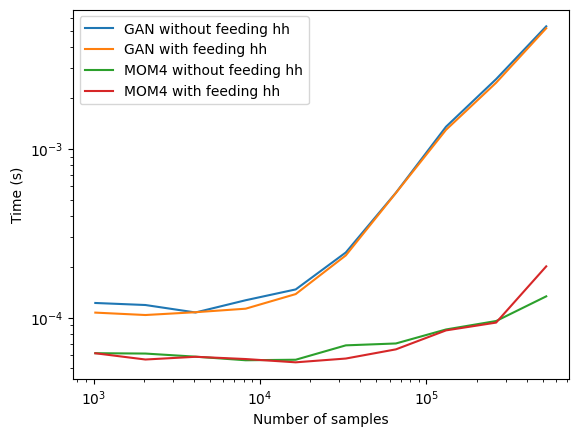

In [11]:
# Plot how the time of both methods changes with the number of samples
import matplotlib.pyplot as plt

num_samples = 2 ** np.arange(10, 20)
times_gan_without_hh = np.zeros_like(num_samples, dtype=float)
times_gan_with_hh = np.zeros_like(num_samples, dtype=float)
times_mom4_without_hh = np.zeros_like(num_samples, dtype=float)
times_mom4_with_hh = np.zeros_like(num_samples, dtype=float)

for i, n in enumerate(num_samples):
    tg_without, tg_with = compute_time(4, 16, 3, 4, n, use_gan=True, print_results=False)
    times_gan_without_hh[i] = tg_without
    times_gan_with_hh[i] = tg_with
    tm_without, tm_with = compute_time(4, 16, 3, 4, n, use_gan=False, print_results=False)
    times_mom4_without_hh[i] = tm_without
    times_mom4_with_hh[i] = tm_with
    print(f"Ratio for {n} samples: without hh: {tg_without/tm_without:.4}, with hh: {tg_with/tm_with:.4}")

plt.figure()
plt.plot(num_samples, times_gan_without_hh, label="GAN without feeding hh")
plt.plot(num_samples, times_gan_with_hh, label="GAN with feeding hh")
plt.plot(num_samples, times_mom4_without_hh, label="MOM4 without feeding hh")
plt.plot(num_samples, times_mom4_with_hh, label="MOM4 with feeding hh")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of samples")
plt.ylabel("Time (s)")
plt.legend()